In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib
import pickle

In [2]:
# Load the dataset
file_path = "color_base_dataset.csv"
data = pd.read_csv(file_path)

In [3]:
# Define input features (X) and target outputs (y)
X = data[["temperature", "humidity", "lux_level", "week"]]
y = data[["R", "G", "B"]]

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Create a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [6]:
# Train the model on the training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
# Save the trained model
with open('rgb_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print(f"Model saved")

Model saved


In [8]:
# Load the model for prediction
loaded_model = joblib.load('rgb_model.pkl')

In [9]:
# Make predictions on the testing data
y_pred = loaded_model.predict(X_test)

In [10]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 36.35719766666667


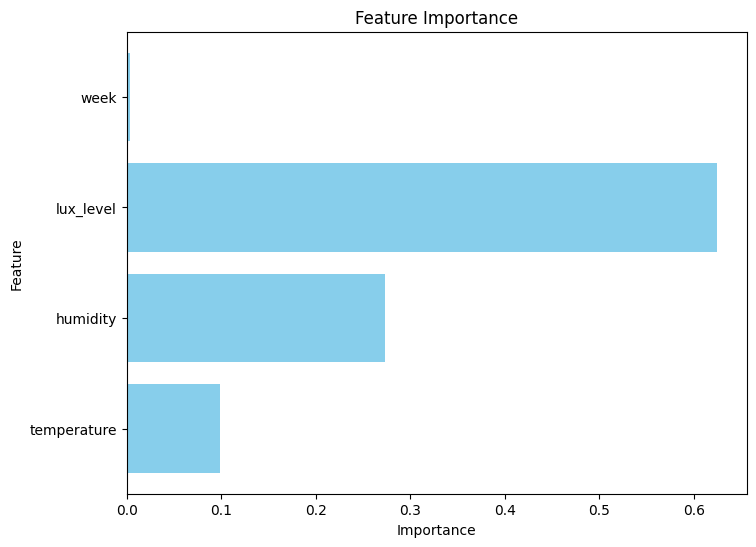

In [11]:
# Feature importance plot
feature_importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

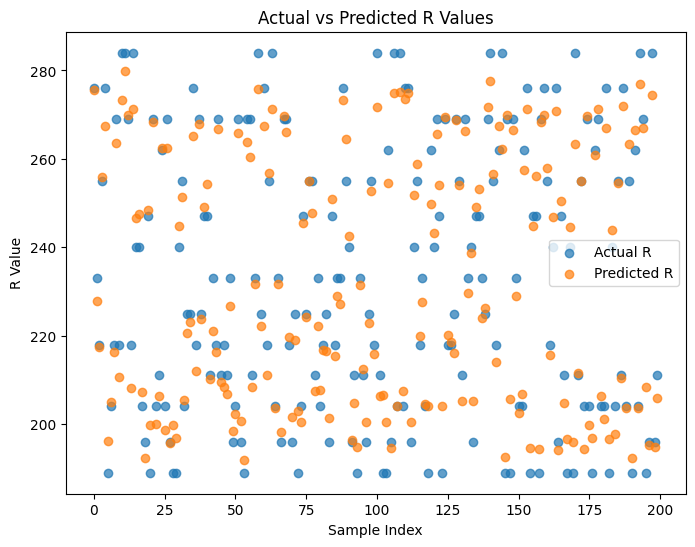

In [12]:
# Actual vs Predicted plot for one of the RGB channels (e.g., R)
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_test["R"], label='Actual R', alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred[:, 0], label='Predicted R', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('R Value')
plt.title('Actual vs Predicted R Values')
plt.legend()
plt.show()

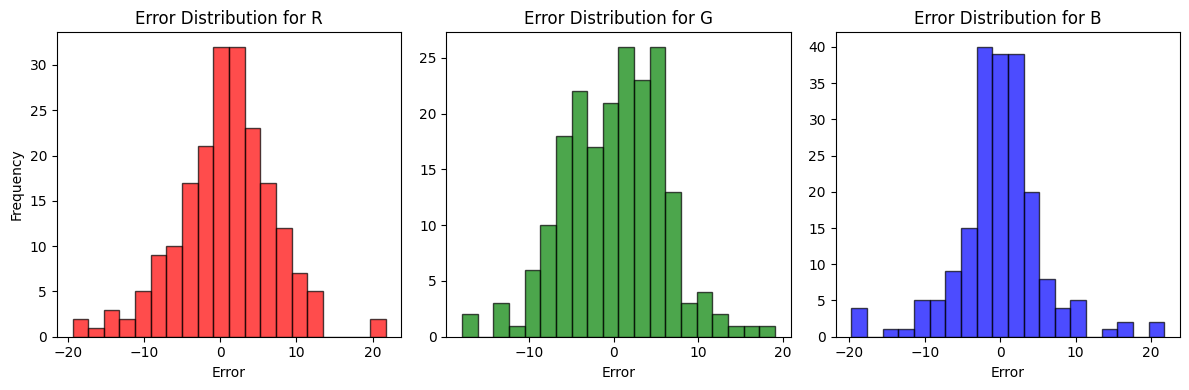

In [13]:
# Compute errors for R, G, B
errors = y_test - y_pred
error_r = errors["R"]
error_g = errors["G"]
error_b = errors["B"]

# Plot error histograms
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(error_r, bins=20, color='red', alpha=0.7, edgecolor='black')
plt.title('Error Distribution for R')
plt.xlabel('Error')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(error_g, bins=20, color='green', alpha=0.7, edgecolor='black')
plt.title('Error Distribution for G')
plt.xlabel('Error')

plt.subplot(1, 3, 3)
plt.hist(error_b, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title('Error Distribution for B')
plt.xlabel('Error')
plt.tight_layout()
plt.show()


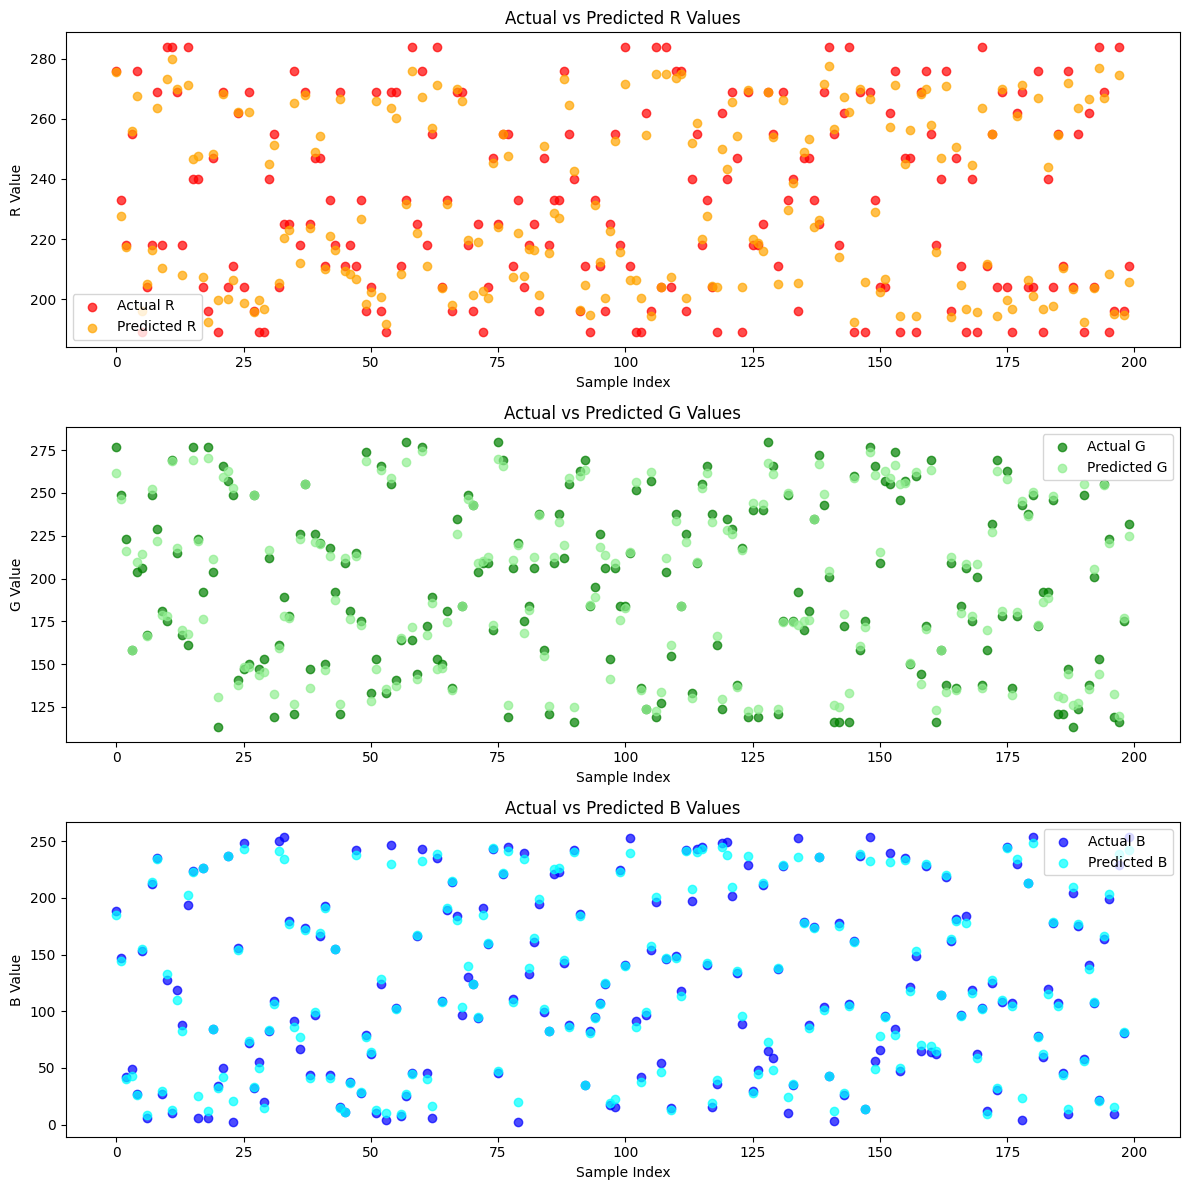

In [14]:
# Actual vs Predicted plots for R, G, B
plt.figure(figsize=(12, 12))

# Plot for R
plt.subplot(3, 1, 1)
plt.scatter(range(len(y_test)), y_test["R"], label='Actual R', alpha=0.7, color='red')
plt.scatter(range(len(y_pred)), y_pred[:, 0], label='Predicted R', alpha=0.7, color='orange')
plt.xlabel('Sample Index')
plt.ylabel('R Value')
plt.title('Actual vs Predicted R Values')
plt.legend()

# Plot for G
plt.subplot(3, 1, 2)
plt.scatter(range(len(y_test)), y_test["G"], label='Actual G', alpha=0.7, color='green')
plt.scatter(range(len(y_pred)), y_pred[:, 1], label='Predicted G', alpha=0.7, color='lightgreen')
plt.xlabel('Sample Index')
plt.ylabel('G Value')
plt.title('Actual vs Predicted G Values')
plt.legend()

# Plot for B
plt.subplot(3, 1, 3)
plt.scatter(range(len(y_test)), y_test["B"], label='Actual B', alpha=0.7, color='blue')
plt.scatter(range(len(y_pred)), y_pred[:, 2], label='Predicted B', alpha=0.7, color='cyan')
plt.xlabel('Sample Index')
plt.ylabel('B Value')
plt.title('Actual vs Predicted B Values')
plt.legend()

# Show all plots together
plt.tight_layout()
plt.show()

In [15]:
# Predict R, G, B values for a new input
new_input = pd.DataFrame({
    "temperature": [25],  # Example temperature
    "humidity": [50],     # Example humidity
    "lux_level": [5000],  # Example lux level
    "week": [30]          # Example week
})
predicted_rgb = model.predict(new_input)
print(f"Predicted R, G, B values: {predicted_rgb[0]}")

Predicted R, G, B values: [200.97 134.86 130.21]
